
STEP 1-4: LOAD, VALIDATE, & EDA
[VALIDATION] Dataset passed all integrity checks.

----------------------------------------------------------------------
Dataset Preview (first 5 rows)
----------------------------------------------------------------------


,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0



----------------------------------------------------------------------
Dataset Shape
----------------------------------------------------------------------
Rows: 1372, Columns: 5

----------------------------------------------------------------------
Descriptive Statistics
----------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
variance,1372.0,0.433735,2.842763,-7.0421,-1.773000,0.49618,2.821475,6.8248
skewness,1372.0,1.922353,5.869047,-13.7731,-1.708200,2.31965,6.814625,12.9516
curtosis,1372.0,1.397627,4.310030,-5.2861,-1.574975,0.61663,3.179250,17.9274
entropy,1372.0,-1.191657,2.101013,-8.5482,-2.413450,-0.58665,0.394810,2.4495
class,1372.0,0.444606,0.497103,0.0000,0.000000,0.00000,1.000000,1.0000



----------------------------------------------------------------------
Class Distribution
----------------------------------------------------------------------


,count,percentage
class,,
0,762,55.54
1,610,44.46



----------------------------------------------------------------------
Correlation Matrix
----------------------------------------------------------------------


,variance,skewness,curtosis,entropy,class
variance,1.000,0.264,-0.381,0.277,-0.725
skewness,0.264,1.000,-0.787,-0.526,-0.445
curtosis,-0.381,-0.787,1.000,0.319,0.156
entropy,0.277,-0.526,0.319,1.000,-0.023
class,-0.725,-0.445,0.156,-0.023,1.000



STEP 5: GENERATING EDA PLOTS


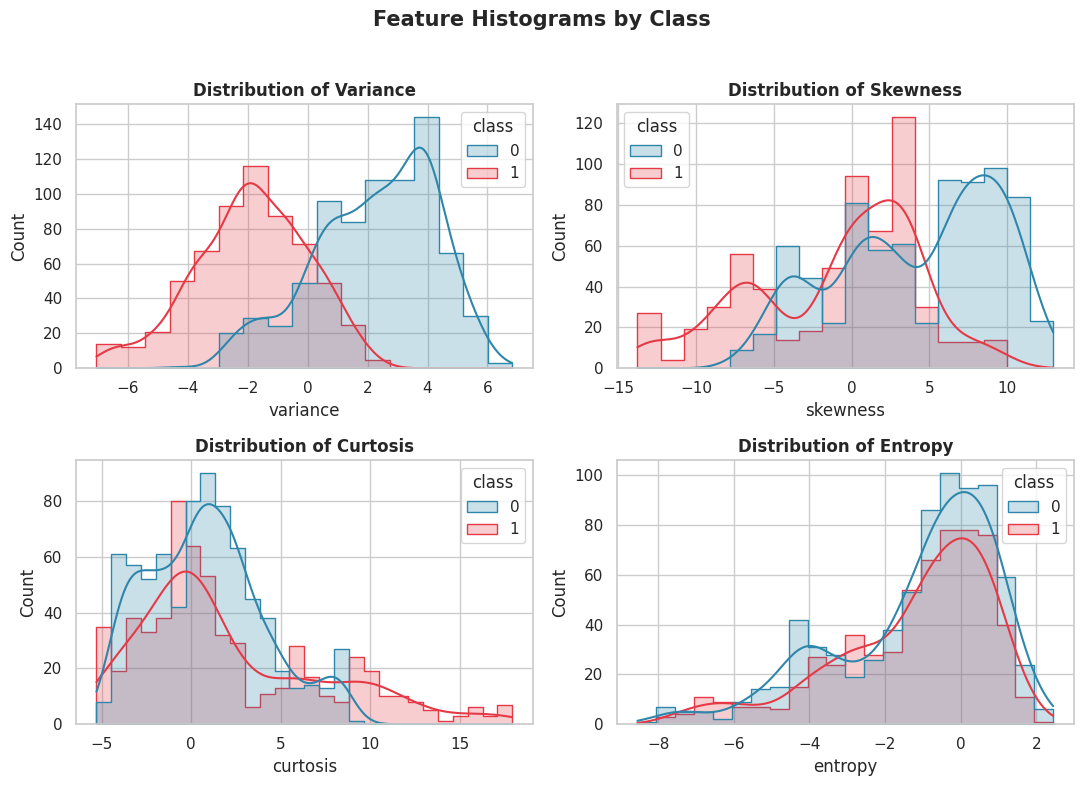

[PLOT SAVED] plots/feature_histograms.png



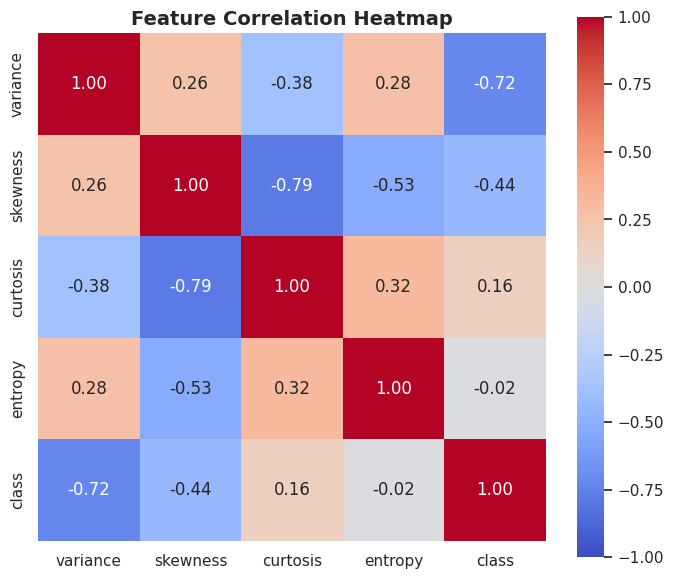

[PLOT SAVED] plots/correlation_heatmap.png



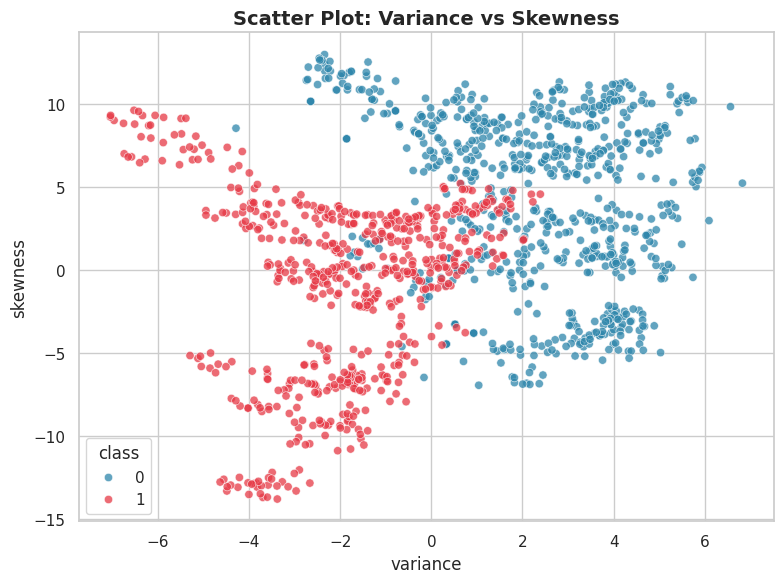

[PLOT SAVED] plots/scatter_plot.png



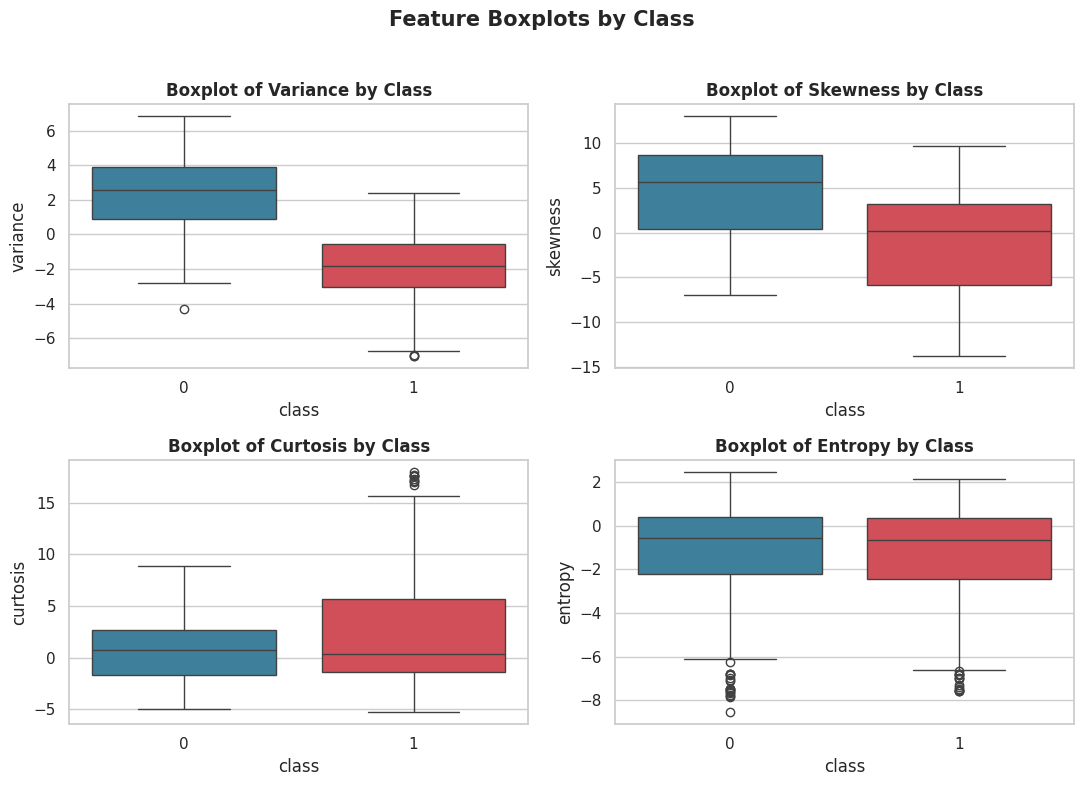

[PLOT SAVED] plots/boxplots.png


STEP 6-7: NORMALIZATION AND SPLIT

STEP 8-12: TRAINING & EVALUATING PERCEPTRON (eta=0.01)
Epoch  10 | Misclassified:   21 | bias=-0.0500
Epoch  20 | Misclassified:   17 | bias=-0.0900
Epoch  30 | Misclassified:   15 | bias=-0.0900
Epoch  40 | Misclassified:   19 | bias=-0.0900
Epoch  50 | Misclassified:   11 | bias=-0.0900
Epoch  60 | Misclassified:   16 | bias=-0.1100
Epoch  70 | Misclassified:   18 | bias=-0.1100
Epoch  80 | Misclassified:   12 | bias=-0.1200
Epoch  90 | Misclassified:   14 | bias=-0.1200
Epoch 100 | Misclassified:   15 | bias=-0.1300
[SAVED] outputs/epoch_history.csv
Test Accuracy: 0.9781


GENERATING TRAINING PLOTS


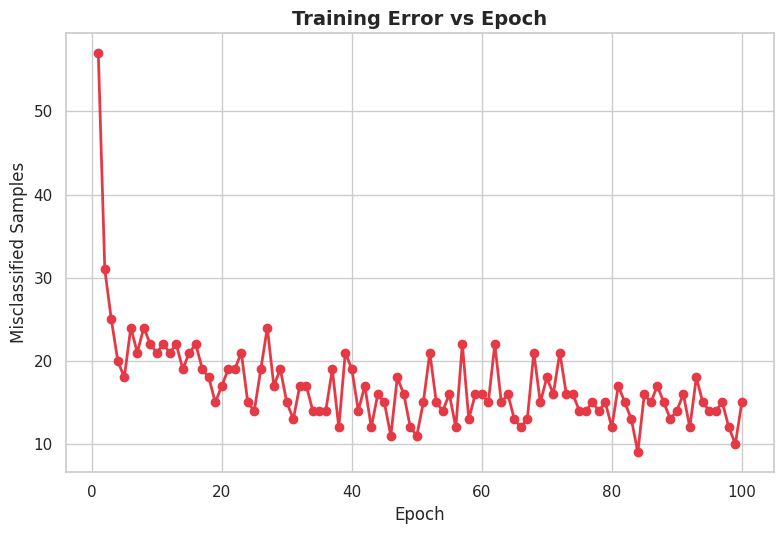

[PLOT SAVED] plots/training_error_vs_epoch.png



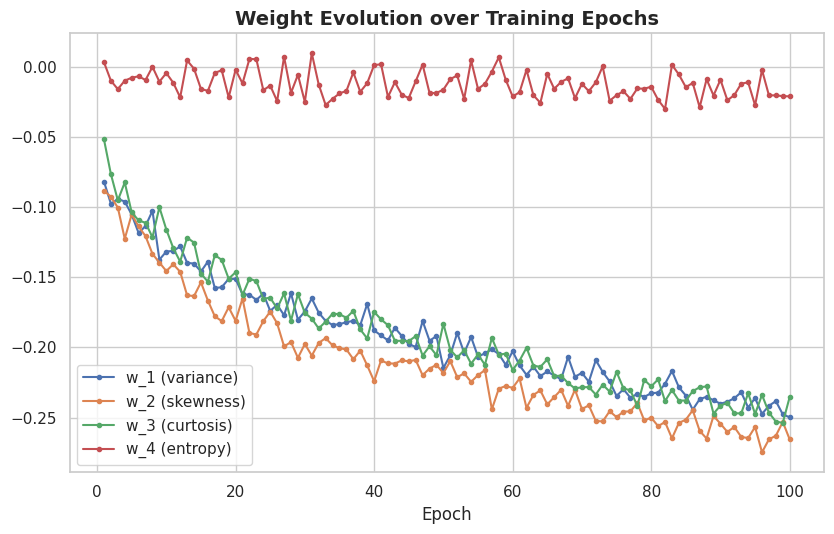

[PLOT SAVED] plots/weight_evolution.png



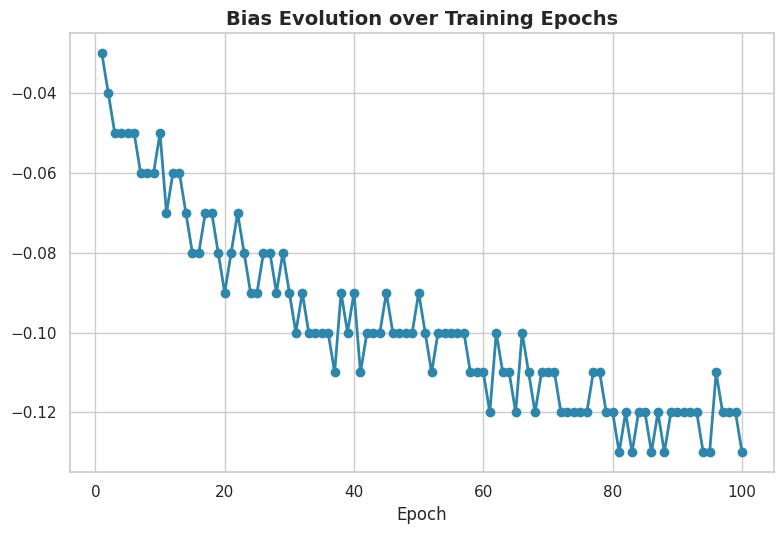

[PLOT SAVED] plots/bias_evolution.png



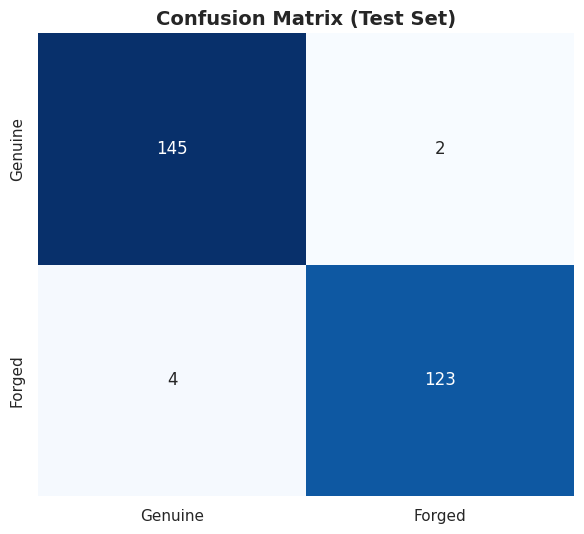

[PLOT SAVED] plots/confusion_matrix.png



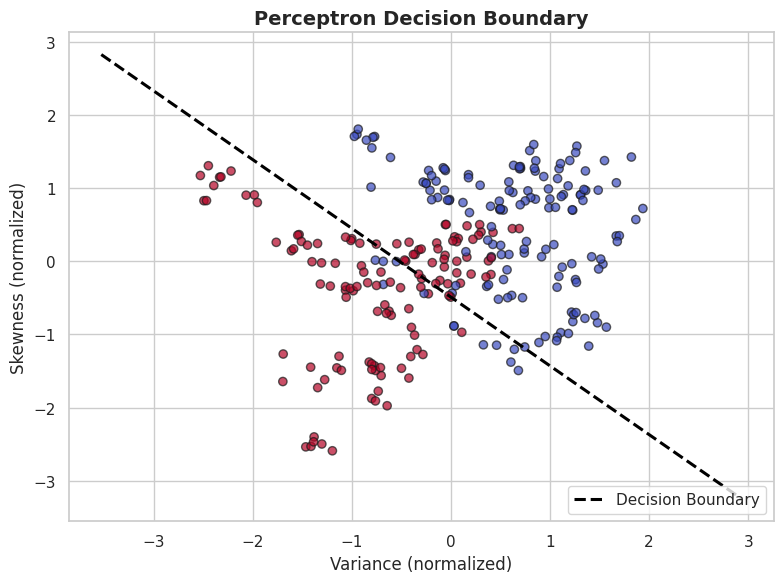

[PLOT SAVED] plots/decision_boundary.png


STEP 13: LEARNING RATE COMPARISON (LINE CHART)


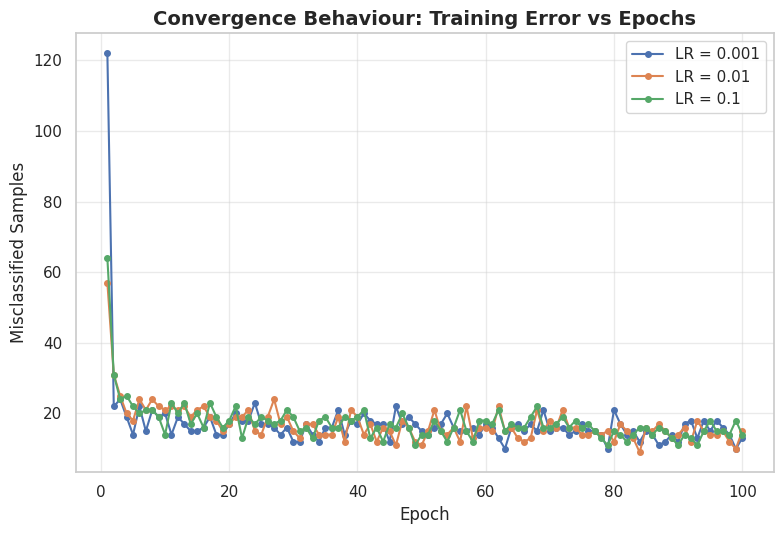

[PLOT SAVED] plots/learning_rate_comparison.png


ZIPPING AND DOWNLOADING RESULTS


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloads triggered. You should receive 'outputs.zip' and 'plots.zip' shortly.


In [ ]:
# ==============================================================================
# CS3807 Deep Learning Laboratory - Experiment 1
# Implementation of a Single Layer Perceptron from Scratch
# ==============================================================================

import os
import random
import urllib.request
import shutil
from typing import List, Optional, Sequence, Tuple
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from google.colab import files
    from IPython.display import display
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    def display(obj): print(obj)

sns.set_theme(style="whitegrid", context="notebook")

# ------------------------------------------------------------------------------
# 1. Constants & Configuration
# ------------------------------------------------------------------------------
RANDOM_SEED = 42
FEATURE_COLUMNS = ["variance", "skewness", "curtosis", "entropy"]
TARGET_COLUMN = "class"
COLUMN_NAMES = FEATURE_COLUMNS + [TARGET_COLUMN]

PRIMARY_LEARNING_RATE = 0.01
N_EPOCHS = 100
TEST_SIZE = 0.2
LEARNING_RATES_TO_COMPARE = [0.001, 0.01, 0.1]
DPI = 300

OUTPUTS_DIR = "outputs"
PLOTS_DIR = "plots"
REPORT_FIGURES_DIR = "report/figures"

DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"
DATA_PATH = "data/data_banknote_authentication.txt"


# ------------------------------------------------------------------------------
# 2. Utils
# ------------------------------------------------------------------------------
def set_global_seed(seed: int = RANDOM_SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)

def ensure_directories(paths: Sequence[str]) -> None:
    for path in paths:
        os.makedirs(path, exist_ok=True)

def print_section(title: str) -> None:
    line = "=" * 70
    print(f"\n{line}\n{title}\n{line}")

def print_subsection(title: str) -> None:
    line = "-" * 70
    print(f"\n{line}\n{title}\n{line}")

def save_dataframe(df: pd.DataFrame, path: str, index: bool = False) -> None:
    os.makedirs(os.path.dirname(path), exist_ok=True)
    df.to_csv(path, index=index)
    print(f"[SAVED] {path}")


# ------------------------------------------------------------------------------
# 3. Preprocessing
# ------------------------------------------------------------------------------
def load_dataset(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, header=None, names=COLUMN_NAMES)
    return df

def validate_dataset(df: pd.DataFrame) -> None:
    if df.shape[1] != len(COLUMN_NAMES):
        raise ValueError(f"Expected {len(COLUMN_NAMES)} columns, found {df.shape[1]}.")
    if df.isnull().values.any():
        raise ValueError("Dataset contains missing (NaN) values.")
    unique_labels = set(df["class"].unique().tolist())
    if not unique_labels.issubset({0, 1}):
        raise ValueError(f"Target column must be binary {{0, 1}}, found labels: {unique_labels}")
    non_numeric = df.drop(columns=["class"]).select_dtypes(exclude=[np.number])
    if not non_numeric.empty:
        raise ValueError("Feature columns must all be numeric.")
    print("[VALIDATION] Dataset passed all integrity checks.")

def summarize_dataset(df: pd.DataFrame) -> pd.DataFrame:
    return df.describe().T

def normalize_features(features: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    means = features.mean(axis=0)
    stds = features.std(axis=0)
    stds[stds == 0] = 1.0
    normalized = (features - means) / stds
    return normalized, means, stds

def train_test_split_manual(
    features: np.ndarray, labels: np.ndarray, test_size: float = 0.2, seed: int = 42
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    n_samples = features.shape[0]
    rng = np.random.RandomState(seed)
    indices = rng.permutation(n_samples)
    n_test = int(np.floor(n_samples * test_size))
    test_indices, train_indices = indices[:n_test], indices[n_test:]
    return features[train_indices], features[test_indices], labels[train_indices], labels[test_indices]


# ------------------------------------------------------------------------------
# 4. EDA
# ------------------------------------------------------------------------------
def class_distribution(df: pd.DataFrame) -> pd.DataFrame:
    counts = df["class"].value_counts().sort_index()
    percentages = (counts / len(df) * 100).round(2)
    result = pd.DataFrame({"count": counts, "percentage": percentages})
    result.index.name = "class"
    return result

def correlation_matrix(df: pd.DataFrame) -> pd.DataFrame:
    return df.corr()

def run_eda(df: pd.DataFrame) -> None:
    print_subsection("Dataset Preview (first 5 rows)")
    display(df.head())
    print_subsection("Dataset Shape")
    print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
    print_subsection("Descriptive Statistics")
    display(df.describe().T)
    print_subsection("Class Distribution")
    display(class_distribution(df))
    print_subsection("Correlation Matrix")
    display(correlation_matrix(df).round(3))


# ------------------------------------------------------------------------------
# 5. Evaluation
# ------------------------------------------------------------------------------
@dataclass
class ClassificationMetrics:
    accuracy: float
    precision: float
    recall: float
    f1_score: float
    confusion_matrix: np.ndarray

def compute_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))
    return np.array([[tn, fp], [fn, tp]])

def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> ClassificationMetrics:
    cm = compute_confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
    accuracy = (tp + tn) / cm.sum() if cm.sum() > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1_score = (2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0)
    return ClassificationMetrics(accuracy, precision, recall, f1_score, cm)


# ------------------------------------------------------------------------------
# 6. Model
# ------------------------------------------------------------------------------
class SingleLayerPerceptron:
    def __init__(self, learning_rate: float = 0.01, n_epochs: int = 100, random_seed: int = 42, verbose: bool = True) -> None:
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.random_seed = random_seed
        self.verbose = verbose
        self.weights: Optional[np.ndarray] = None
        self.bias: float = 0.0
        self.epoch_history: List[dict] = []
        self.converged_epoch: Optional[int] = None

    def initialize_parameters(self, n_features: int) -> None:
        rng = np.random.RandomState(self.random_seed)
        self.weights = rng.uniform(-0.05, 0.05, size=n_features)
        self.bias = 0.0
        self.epoch_history = []
        self.converged_epoch = None

    @staticmethod
    def step_activation(z: np.ndarray) -> np.ndarray:
        return np.where(z >= 0, 1, 0)

    def forward(self, X: np.ndarray) -> np.ndarray:
        return X @ self.weights + self.bias

    def predict(self, X: np.ndarray) -> np.ndarray:
        return self.step_activation(self.forward(X))

    def fit(self, X: np.ndarray, y: np.ndarray) -> "SingleLayerPerceptron":
        n_samples, n_features = X.shape
        self.initialize_parameters(n_features)

        for epoch in range(1, self.n_epochs + 1):
            misclassified = 0
            for idx in range(n_samples):
                x_i, y_i = X[idx], y[idx]
                z = np.dot(self.weights, x_i) + self.bias
                y_hat = 1 if z >= 0 else 0
                error = y_i - y_hat

                if error != 0:
                    misclassified += 1
                    self.weights += self.learning_rate * error * x_i
                    self.bias += self.learning_rate * error

            record = {
                "epoch": epoch,
                "errors": misclassified,
                **{f"weight_{i+1}": self.weights[i] for i in range(n_features)},
                "bias": self.bias,
            }
            self.epoch_history.append(record)

            if self.verbose and epoch % 10 == 0:
                print(f"Epoch {epoch:3d} | Misclassified: {misclassified:4d} | bias={self.bias:.4f}")

            if misclassified == 0:
                self.converged_epoch = epoch
                if self.verbose:
                    print(f"[CONVERGED] Training converged at epoch {epoch}")
                break
        return self

    def get_epoch_history_df(self) -> pd.DataFrame:
        return pd.DataFrame(self.epoch_history)


# ------------------------------------------------------------------------------
# 7. Visualization
# ------------------------------------------------------------------------------
def _save_figure(fig: plt.Figure, output_dir: str, filename: str) -> str:
    os.makedirs(output_dir, exist_ok=True)
    path = os.path.join(output_dir, filename)
    fig.savefig(path, dpi=DPI, bbox_inches="tight")
    plt.show()  # Display plot inline in Colab
    print(f"[PLOT SAVED] {path}\n")
    return path

def plot_feature_histograms(df: pd.DataFrame, output_dir: str) -> str:
    fig, axes = plt.subplots(2, 2, figsize=(11, 8))
    for ax, col in zip(axes.flatten(), FEATURE_COLUMNS):
        sns.histplot(data=df, x=col, hue="class", kde=True, ax=ax, palette=["#2E86AB", "#E63946"], element="step")
        ax.set_title(f"Distribution of {col.capitalize()}", fontsize=12, fontweight="bold")
    fig.suptitle("Feature Histograms by Class", fontsize=15, fontweight="bold")
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    return _save_figure(fig, output_dir, "feature_histograms.png")

def plot_correlation_heatmap(df: pd.DataFrame, output_dir: str) -> str:
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True, ax=ax)
    ax.set_title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
    fig.tight_layout()
    return _save_figure(fig, output_dir, "correlation_heatmap.png")

def plot_scatter(df: pd.DataFrame, output_dir: str, x: str = "variance", y: str = "skewness") -> str:
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.scatterplot(data=df, x=x, y=y, hue="class", palette=["#2E86AB", "#E63946"], alpha=0.75, ax=ax)
    ax.set_title(f"Scatter Plot: {x.capitalize()} vs {y.capitalize()}", fontsize=14, fontweight="bold")
    fig.tight_layout()
    return _save_figure(fig, output_dir, "scatter_plot.png")

def plot_boxplots(df: pd.DataFrame, output_dir: str) -> str:
    fig, axes = plt.subplots(2, 2, figsize=(11, 8))
    for ax, col in zip(axes.flatten(), FEATURE_COLUMNS):
        sns.boxplot(data=df, x="class", y=col, hue="class", ax=ax, palette=["#2E86AB", "#E63946"], legend=False)
        ax.set_title(f"Boxplot of {col.capitalize()} by Class", fontsize=12, fontweight="bold")
    fig.suptitle("Feature Boxplots by Class", fontsize=15, fontweight="bold")
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    return _save_figure(fig, output_dir, "boxplots.png")

def plot_training_error_curve(epoch_history: pd.DataFrame, output_dir: str) -> str:
    fig, ax = plt.subplots(figsize=(8, 5.5))
    ax.plot(epoch_history["epoch"], epoch_history["errors"], marker="o", color="#E63946", linewidth=2)
    ax.set_title("Training Error vs Epoch", fontsize=14, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Misclassified Samples")
    fig.tight_layout()
    return _save_figure(fig, output_dir, "training_error_vs_epoch.png")

def plot_weight_evolution(epoch_history: pd.DataFrame, feature_names: Sequence[str], output_dir: str) -> str:
    fig, ax = plt.subplots(figsize=(8.5, 5.5))
    for i, name in enumerate(feature_names):
        ax.plot(epoch_history["epoch"], epoch_history[f"weight_{i+1}"], marker="o", markersize=3, label=f"w_{i+1} ({name})")
    ax.set_title("Weight Evolution over Training Epochs", fontsize=14, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.legend(loc="best")
    fig.tight_layout()
    return _save_figure(fig, output_dir, "weight_evolution.png")

def plot_bias_evolution(epoch_history: pd.DataFrame, output_dir: str) -> str:
    fig, ax = plt.subplots(figsize=(8, 5.5))
    ax.plot(epoch_history["epoch"], epoch_history["bias"], marker="o", color="#2E86AB", linewidth=2)
    ax.set_title("Bias Evolution over Training Epochs", fontsize=14, fontweight="bold")
    ax.set_xlabel("Epoch")
    fig.tight_layout()
    return _save_figure(fig, output_dir, "bias_evolution.png")

def plot_confusion_matrix(cm: np.ndarray, output_dir: str) -> str:
    fig, ax = plt.subplots(figsize=(6, 5.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=["Genuine", "Forged"], yticklabels=["Genuine", "Forged"], ax=ax)
    ax.set_title("Confusion Matrix (Test Set)", fontsize=14, fontweight="bold")
    fig.tight_layout()
    return _save_figure(fig, output_dir, "confusion_matrix.png")

def plot_decision_boundary(X: np.ndarray, y: np.ndarray, weights: np.ndarray, bias: float, output_dir: str) -> str:
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", alpha=0.7, edgecolors="k")
    x_vals = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200)
    if abs(weights[1]) > 1e-8:
        y_vals = -(weights[0] * x_vals + bias) / weights[1]
        ax.plot(x_vals, y_vals, color="black", linewidth=2.2, linestyle="--", label="Decision Boundary")
        ax.legend(loc="lower right")
    ax.set_title("Perceptron Decision Boundary", fontsize=14, fontweight="bold")
    ax.set_xlabel(FEATURE_COLUMNS[0].capitalize() + " (normalized)")
    ax.set_ylabel(FEATURE_COLUMNS[1].capitalize() + " (normalized)")
    fig.tight_layout()
    return _save_figure(fig, output_dir, "decision_boundary.png")

def plot_learning_rate_comparison_lines(lr_histories: dict, output_dir: str) -> str:
    fig, ax = plt.subplots(figsize=(8, 5.5))
    for lr, history in lr_histories.items():
        ax.plot(history["epoch"], history["errors"], marker="o", markersize=4, label=f"LR = {lr}")

    ax.set_title("Convergence Behaviour: Training Error vs Epochs", fontsize=14, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Misclassified Samples")
    ax.legend()
    ax.grid(True, alpha=0.4)
    fig.tight_layout()
    return _save_figure(fig, output_dir, "learning_rate_comparison.png")


# ------------------------------------------------------------------------------
# 8. Main Execution
# ------------------------------------------------------------------------------
def main():
    set_global_seed(RANDOM_SEED)
    ensure_directories([OUTPUTS_DIR, PLOTS_DIR, REPORT_FIGURES_DIR])

    if not os.path.exists(DATA_PATH):
        print(f"Downloading dataset to {DATA_PATH}...")
        urllib.request.urlretrieve(DATA_URL, DATA_PATH)

    print_section("STEP 1-4: LOAD, VALIDATE, & EDA")
    df = load_dataset(DATA_PATH)
    validate_dataset(df)
    run_eda(df)

    print_section("STEP 5: GENERATING EDA PLOTS")
    plot_feature_histograms(df, PLOTS_DIR)
    plot_correlation_heatmap(df, PLOTS_DIR)
    plot_scatter(df, PLOTS_DIR)
    plot_boxplots(df, PLOTS_DIR)

    print_section("STEP 6-7: NORMALIZATION AND SPLIT")
    X_raw = df[FEATURE_COLUMNS].to_numpy(dtype=float)
    y = df[TARGET_COLUMN].to_numpy(dtype=int)
    X_norm, _, _ = normalize_features(X_raw)
    X_train, X_test, y_train, y_test = train_test_split_manual(X_norm, y, TEST_SIZE, RANDOM_SEED)

    print_section(f"STEP 8-12: TRAINING & EVALUATING PERCEPTRON (eta={PRIMARY_LEARNING_RATE})")
    model = SingleLayerPerceptron(learning_rate=PRIMARY_LEARNING_RATE, n_epochs=N_EPOCHS, random_seed=RANDOM_SEED)
    model.fit(X_train, y_train)
    epoch_history_df = model.get_epoch_history_df()
    save_dataframe(epoch_history_df, f"{OUTPUTS_DIR}/epoch_history.csv")

    y_pred_test = model.predict(X_test)
    metrics = compute_metrics(y_test, y_pred_test)
    print(f"Test Accuracy: {metrics.accuracy:.4f}\n")

    print_section("GENERATING TRAINING PLOTS")
    plot_training_error_curve(epoch_history_df, PLOTS_DIR)
    plot_weight_evolution(epoch_history_df, FEATURE_COLUMNS, PLOTS_DIR)
    plot_bias_evolution(epoch_history_df, PLOTS_DIR)
    plot_confusion_matrix(metrics.confusion_matrix, PLOTS_DIR)
    plot_decision_boundary(X_test, y_test, model.weights, model.bias, PLOTS_DIR)

    print_section("STEP 13: LEARNING RATE COMPARISON (LINE CHART)")
    lr_histories = {}
    for lr in LEARNING_RATES_TO_COMPARE:
        lr_model = SingleLayerPerceptron(learning_rate=lr, n_epochs=N_EPOCHS, random_seed=RANDOM_SEED, verbose=False)
        lr_model.fit(X_train, y_train)
        lr_histories[lr] = lr_model.get_epoch_history_df()

    plot_learning_rate_comparison_lines(lr_histories, PLOTS_DIR)

    if IN_COLAB:
        print_section("ZIPPING AND DOWNLOADING RESULTS")
        shutil.make_archive("outputs", 'zip', OUTPUTS_DIR)
        shutil.make_archive("plots", 'zip', PLOTS_DIR)
        files.download("outputs.zip")
        files.download("plots.zip")
        print("Downloads triggered. You should receive 'outputs.zip' and 'plots.zip' shortly.")

if __name__ == "__main__":
    main()